<a href="https://colab.research.google.com/github/oliveirangel/curso_dados/blob/main/Analise_Renda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Renda Per Capita:** avalia o grau de desenvolvimento economico de um determinado local. Obtida atraves da divisão do PNB pelo número de habitantes.

**PIB (Produto Interno Bruto):** Soma tudo o que foi produzido dentro do Brasil, mesmo que por filiais de empresas multinacionais.

**PNB (Produto Nacional Bruto):** Soma tudo o que empresas de capital brasileiro produziram (tanto aqui quanto suas filiais em outros países) e exclui a produção de empresas estrangeiras em território nacional.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Base_Renda = pd.read_excel('Dados_Pib.xlsx')

Base_Renda.head(15)

,Territorialidades,Ano,PIB per capita
0,Brasil,2013,22.20
1,Acre,2013,12.37
2,Alagoas,2013,9.45
3,Amapá,2013,14.53
4,Amazonas,2013,18.25
5,Bahia,2013,11.40
6,Ceará,2013,10.40
7,Distrito Federal,2013,52.77
8,Espírito Santo,2013,25.56
9,Goiás,2013,19.68


In [ ]:
Base_Renda.groupby(by=['Territorialidades']).mean() #Calculando a média de cada estado

,Ano,PIB per capita
Territorialidades,,
Acre,2014.5,12.3000
Alagoas,2014.5,9.7400
Amapá,2014.5,13.4500
Amazonas,2014.5,16.6250
Bahia,2014.5,11.4825
Brasil,2014.5,21.5000
Ceará,2014.5,10.6150
Distrito Federal,2014.5,53.2925
Espírito Santo,2014.5,23.0025


In [ ]:
Base_Renda.groupby(by=['Territorialidades', 'Ano']).mean()

PIB per capita
Territorialidades Ano                 
Acre              2013           12.37
                  2014           13.41
                  2015           12.24
                  2016           11.18
Alagoas           2013            9.45
...                                ...
São Paulo         2016           30.24
Tocantins         2013           13.47
                  2014           13.77
                  2015           13.79
                  2016           13.68

[112 rows x 1 columns]

In [ ]:
Base_Nova = Base_Renda[Base_Renda['Territorialidades'] != 'Brasil']

In [ ]:
Base_Nova.head(15)

,Territorialidades,Ano,PIB per capita
1,Acre,2013,12.37
2,Alagoas,2013,9.45
3,Amapá,2013,14.53
4,Amazonas,2013,18.25
5,Bahia,2013,11.40
6,Ceará,2013,10.40
7,Distrito Federal,2013,52.77
8,Espírito Santo,2013,25.56
9,Goiás,2013,19.68
10,Maranhão,2013,8.34


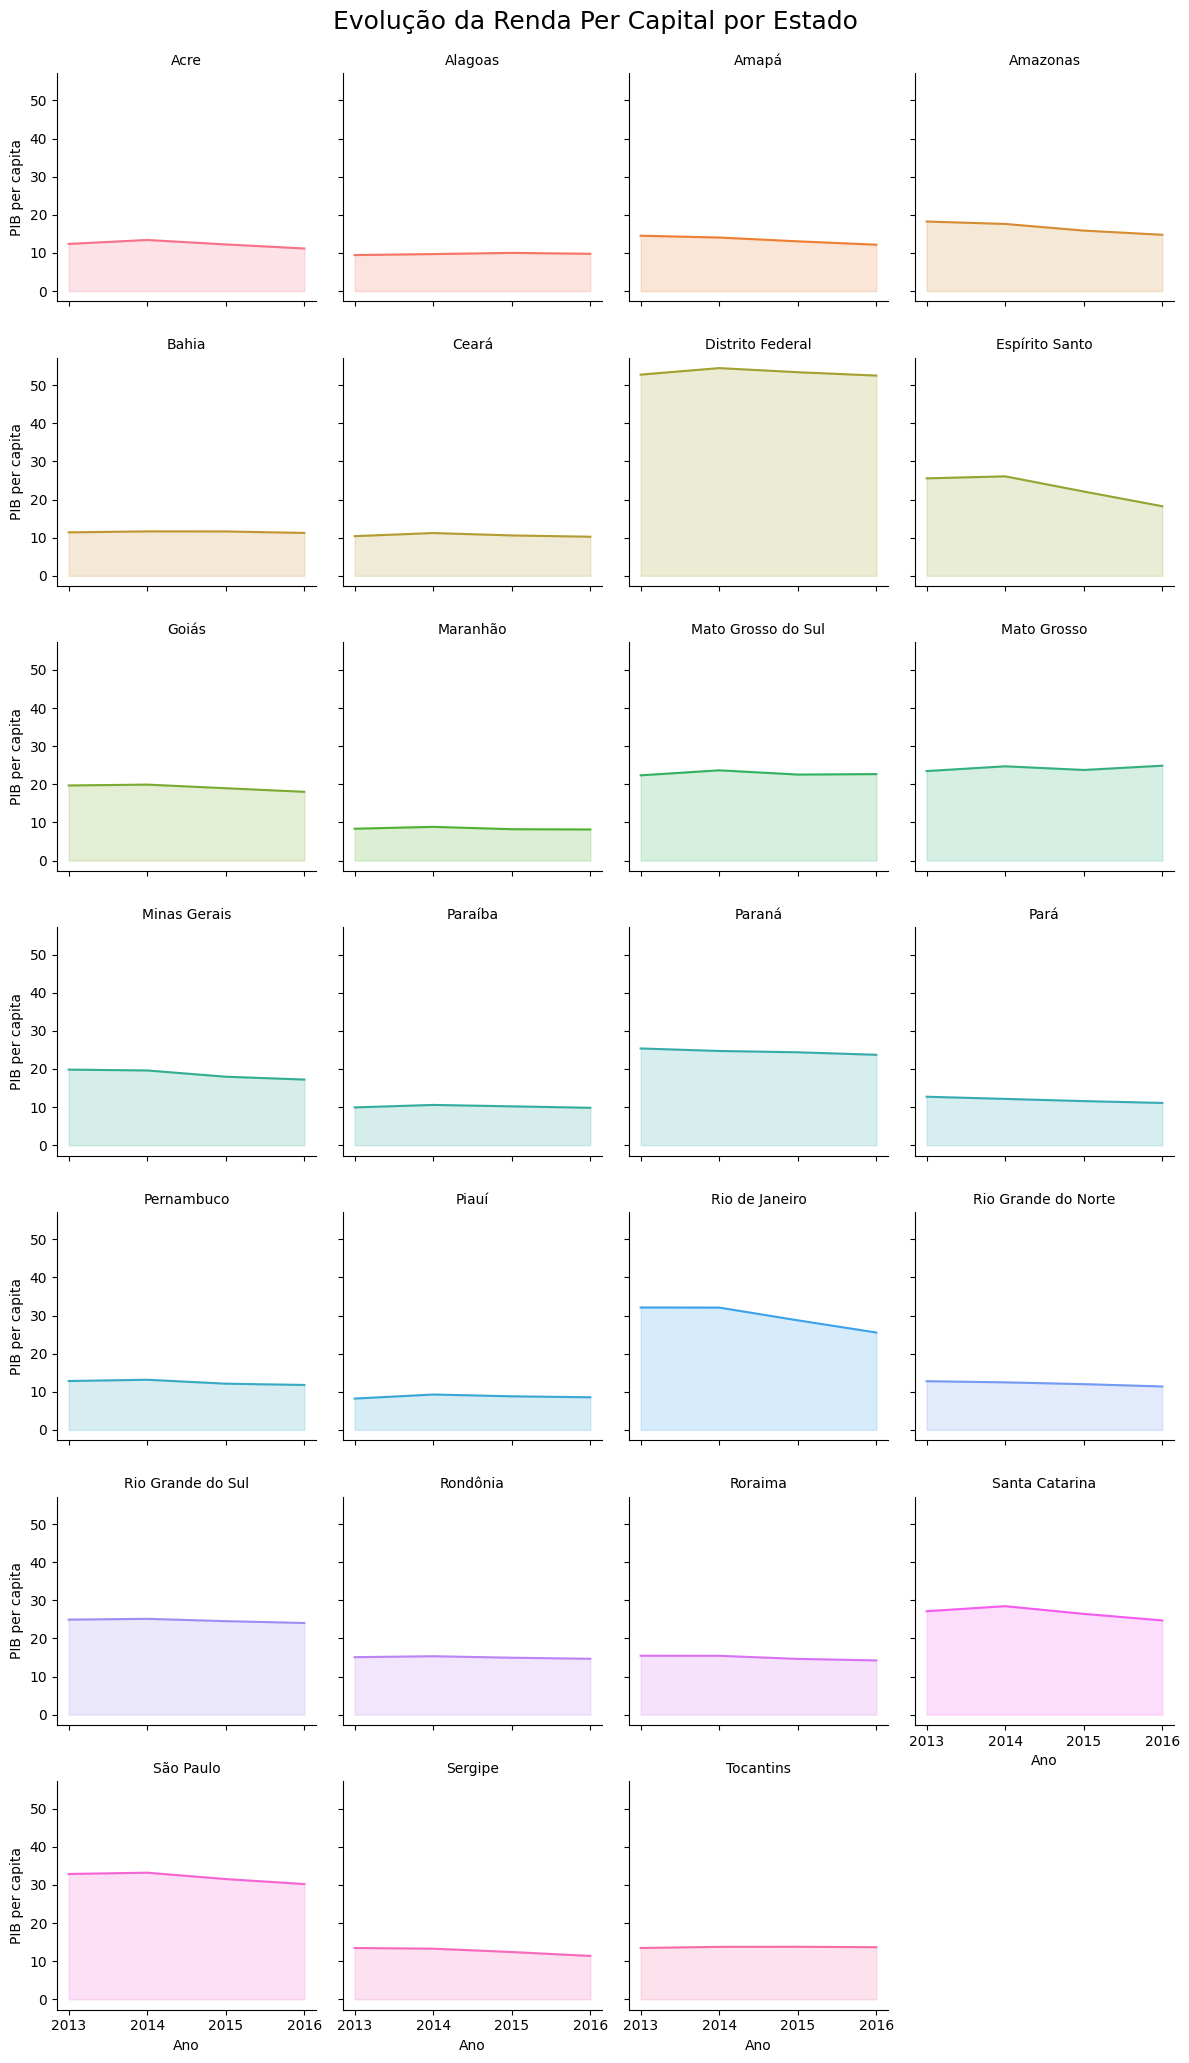

In [21]:
# Sistema de grid (OCUPA BASTANTE MEMORIA)

cor_fundo = 'f5f5f5'

#Criando sistema de grids
#hue - segmentação
Grid_Graficos = sns.FacetGrid(Base_Nova, col='Territorialidades', hue='Territorialidades', col_wrap= 4) #col_wrap - numero de colunas


#Adicionando um gráfico de linhas em cada grid
Grid_Graficos = Grid_Graficos.map(plt.plot, 'Ano', 'PIB per capita')

#Adicionando uma sombra + Ajuste do título
Grid_Graficos = Grid_Graficos.map(plt.fill_between, 'Ano', 'PIB per capita', alpha=0.2).set_titles('{col_name} Territorialidades') #alpha - para clarear a cor da sombra

#Filtrar o título
Grid_Graficos = Grid_Graficos.set_titles('{col_name}')

#Adicionando subtitulo
Grid_Graficos = Grid_Graficos.fig.suptitle(
    'Evolução da Renda Per Capital por Estado',
    fontsize= 18
)

#Ajustando espaçamento entre o subtítulo ('A Evolução...') e os gráficos
plt.subplots_adjust(top=0.95) #ajustando espaçamento entre o subtítulo ('A Evolução...') e os gráficos
